In [1]:
# # Wong-Wang + Cerebellar Mean-Field: Hybrid Simulation & Spectral Analysis
#
# This notebook demonstrates **Wong-Wang (WW) + Cerebellar MF** whole-brain
# simulation using the TVB hybrid framework, with a **construct validation**
# analysis comparing open-loop vs closed-loop cerebellar spectral signatures.
#
# ## Architecture
#
# - **Cortex subnetwork** (99 nodes): 93 cortical + 6 DCN regions,
#   modelled with `ReducedWongWangExcInh`
# - **Cerebellum subnetwork** (27 nodes): cerebellar cortex, modelled with
#   `CerebellarMF` (GrC → GoC → MLI → PC)
#
# ## Signal flow — 4 projections
#
# | # | Type | Signal | Source → Target cvar |
# |---|------|--------|---------------------|
# | P1 | IntraProjection | Intra-cortex | S_e(0) → S_e(0) |
# | P2 | InterProjection | Mossy fibers | S_e(0) → mossy(0) |
# | P3 | InterProjection | GrC feedback | GrC(0) → S_e(0) |
# | P4 | IntraProjection | Parallel fibers | GrC(0) → parallel(1) |

## Scientific Background — Construct Validation
#
A fundamental question in computational neuroscience is whether a model
reproduces the **spectral signatures** observed empirically. This is known
as **construct validation** — demonstrating that the model's intrinsic
dynamics generate oscillations in the expected frequency bands.
#
### Cerebellar oscillation bands
#
Following **Esaghei et al. (2022)** *Trends in Neurosciences*,
we define the canonical frequency bands:
#
| Band | Range (Hz) | Cerebellar relevance |
|------|-----------|----------------------|
| Delta | 1–4 | Slow oscillations, sleep, default-mode |
| Theta | 4–8 | Motor coordination, cerebello-cortical coupling |
| Alpha | 8–13 | **Purkinje cell simple-spike rhythm** |
| Beta | 13–30 | Motor planning, cerebellar synchrony |
| Gamma | 30–100 | Fast local processing, GrC layer |
#
### Population-specific expected spectral profiles
#
| Population | Expected band | Rationale |
|-----------|--------------|----------|
| **GrC** | Gamma / high Beta | Fast input processors with short time constants |
| **GoC** | Beta / Alpha | Slower feedback inhibition gate |
| **MLI** | Alpha / Beta | Intermediate-frequency PC modulation |
| **PC** | Alpha / low Beta | Classic cerebellar output rhythm; best-characterized |
#
### Open-loop vs closed-loop comparison
#
The key construct validation question is:
#
> **Does closing the cortical loop through mossy fibers shift the cerebellar
> spectral profile?**
#
- **Open-loop** (cerebellum isolated): CRBL circuit driven only by noise →
  reveals intrinsic oscillation hierarchy
- **Closed-loop** (whole-brain): cortical S_e drives CRBL via mossy fibers →
  tests whether structured input entrains cerebellar rhythms
#
Empirically, cortical alpha/beta input is expected to enhance PC alpha-band
power and potentially shift GrC oscillations toward lower frequencies.
#
### References
#
- **Lorenzi et al. (2023)** *PLoS Comp Bio* — Cerebellar MF model equations
- **Lorenzi et al. (2025)** *NPJSBA* — Full pipeline & validation results
- **Esaghei et al. (2022)** *Trends Neurosci* — Cerebellar frequency band definitions
- **Goldman et al. (2023)** *Front Comp Neurosci* — Construction pipeline inspiration

In [2]:
%pylab inline
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import scipy.sparse as sp
import scipy.signal

from tvb.simulator.models import ReducedWongWangExcInh
from tvb.simulator.integrators import HeunStochastic
from tvb.simulator.noise import Additive
from tvb.simulator.monitors import TemporalAverage
from tvb.simulator.hybrid import (
    Subnetwork, InterProjection, IntraProjection, NetworkSet, Simulator,
)
from tvb.simulator.models.cerebellar_mf import CerebellarMF

print("All imports OK")

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


All imports OK


## 1. Load structural connectivity
#
126-node AAL+SUIT parcellation: 93 cortical + 6 DCN + 27 cerebellar cortex.
Tract lengths with zero values are replaced with the minimum positive length
(required for delay calculations).

In [3]:
data = np.load('data/conn_126.npz')
W_full = data['weights']
TL_full = data['tract_lengths'].astype(np.float64)
TL_full[TL_full == 0] = np.min(TL_full[TL_full > 0])

print(f"SC: {W_full.shape}, weights [{W_full.min():.4f}, {W_full.max():.4f}]")

SC: (126, 126), weights [0.0000, 1.0000]


## 2. Define region indices

In [4]:
cortex_idx = np.concatenate([
    np.arange(0, 93),                               # 93 cortical
    np.array([103, 104, 105, 113, 114, 115])        # 6 DCN
])
n_cortex = len(cortex_idx)  # 99

crbl_idx = np.array([
    93, 94, 95, 96, 97, 98, 99, 100, 101, 102,
    106, 107, 108, 109, 110, 111, 112,
    116, 117, 118, 119, 120, 121, 122, 123, 124, 125
])
n_crbl = len(crbl_idx)  # 27

dcn_idx = np.array([103, 104, 105, 113, 114, 115])

print(f"Cortex: {n_cortex}, CRBL: {n_crbl}, DCN: {len(dcn_idx)}")

Cortex: 99, CRBL: 27, DCN: 6


## 3. Partition structural connectivity
#
CSR convention: rows=target, cols=source. DCN→CRBL weights are negated.

In [5]:
W = W_full.copy()
W[dcn_idx[:, None], crbl_idx[None, :]] *= -1

def csr(arr): return sp.csr_matrix(arr.astype(np.float64))

W_cc = csr(W[np.ix_(cortex_idx, cortex_idx)])
TL_cc = csr(TL_full[np.ix_(cortex_idx, cortex_idx)])
W_cr = csr(W[np.ix_(crbl_idx, cortex_idx)])   # 27×99
TL_cr = csr(TL_full[np.ix_(crbl_idx, cortex_idx)])
W_rc = csr(W[np.ix_(cortex_idx, crbl_idx)])    # 99×27
TL_rc = csr(TL_full[np.ix_(cortex_idx, crbl_idx)])
W_rr = csr(W[np.ix_(crbl_idx, crbl_idx)])
TL_rr = csr(TL_full[np.ix_(crbl_idx, crbl_idx)])

print(f"W_cc {W_cc.shape}  W_cr {W_cr.shape}  W_rc {W_rc.shape}  W_rr {W_rr.shape}")

W_cc (99, 99)  W_cr (27, 99)  W_rc (99, 27)  W_rr (27, 27)


## 4. Common simulation parameters

In [6]:
dt = 1.0          # ms — adequate for spectral analysis up to 500 Hz
nsig = np.array([(0.001 ** 2) / 2])
sim_len = 10000.0  # 10 seconds
cv = 3.0           # conduction velocity m/s
mon_period = 1.0   # ms — 1 kHz sampling

## 5. Scenario 1 — Open-Loop (Cerebellum Only)
#
The cerebellum in isolation: no cortical drive, only intrinsic CRBL circuit
(GrC → GoC → MLI → PC) with intra-cerebellar parallel fibers (P4).
This reveals the **intrinsic oscillation hierarchy** driven by noise alone.
#
We use per-subnet monitors with `variables_of_interest` set to all 4
neural populations to capture the full spectral profile.

In [7]:
crbl_open = CerebellarMF()
crbl_open.variables_of_interest = ('GrC', 'GoC', 'MLI', 'PC')

cerebellum_open = Subnetwork(
    name='cerebellum', model=crbl_open,
    scheme=HeunStochastic(dt=dt, noise=Additive(nsig=nsig)),
    nnodes=n_crbl, node_indices=crbl_idx,
)

# Only P4: intra-cerebellar parallel fibers
p4 = IntraProjection(
    source_cvar=np.array([0]), target_cvar=np.array([1]),
    weights=W_rr, lengths=TL_rr, cv=cv, dt=dt, scale=1.0,
)
cerebellum_open.projections = [p4]

# Per-subnet monitor: records all 4 CRBL voi
cerebellum_open.add_monitor(TemporalAverage(period=mon_period))

nets_open = NetworkSet(subnets=[cerebellum_open], projections=[])
sim_open = Simulator(
    nets=nets_open, monitors=[TemporalAverage(period=mon_period)],
    simulation_length=sim_len,
)
sim_open.configure()

print("Running open-loop (10 s, CRBL-only)...")
t0 = time.time()
sim_open.run(random_state=42)
elapsed = time.time() - t0
print(f"  Done in {elapsed:.1f} s")

# Extract from per-subnet recorder
rec_crbl_open = cerebellum_open.monitors[0]
ts_open, d_open = rec_crbl_open.to_arrays()
print(f"  CRBL data: {d_open.shape}")   # (n_time, 4, 27, 1)

grc_open = d_open[:, 0, :, 0]  # (n_time, 27)
goc_open = d_open[:, 1, :, 0]
mli_open = d_open[:, 2, :, 0]
pc_open  = d_open[:, 3, :, 0]

print(f"  GrC: mean={grc_open.mean():.2f} range=[{grc_open.min():.2f}, {grc_open.max():.2f}]")
print(f"  PC:  mean={pc_open.mean():.2f} range=[{pc_open.min():.2f}, {pc_open.max():.2f}]")

Running open-loop (10 s, CRBL-only)...


  Done in 4.8 s
  CRBL data: (10000, 4, 27, 1)
  GrC: mean=0.03 range=[0.00, 109.86]
  PC:  mean=0.15 range=[0.00, 102.80]


## 6. Scenario 2 — Closed-Loop (WW + Cerebellum)
#
Full 126-node whole-brain simulation. Cortex S_e drives CRBL via mossy
fibers (P2), CRBL GrC feeds back to cortex S_e (P3), plus intra-cortex
coupling (P1) and intra-CRBL parallel fibers (P4).
#
Per-subnet monitors record all 4 CRBL populations independently,
bypassing the merged global monitor's voi-count constraint.

In [8]:
ww_model = ReducedWongWangExcInh()
ww_model.G = np.array([2.0])
ww_model.J_N = np.array([0.15])

cortex = Subnetwork(
    name='cortex', model=ww_model,
    scheme=HeunStochastic(dt=dt, noise=Additive(nsig=nsig)),
    nnodes=n_cortex, node_indices=cortex_idx,
)

crbl_closed = CerebellarMF()
crbl_closed.variables_of_interest = ('GrC', 'GoC', 'MLI', 'PC')
cerebellum_closed = Subnetwork(
    name='cerebellum', model=crbl_closed,
    scheme=HeunStochastic(dt=dt, noise=Additive(nsig=nsig)),
    nnodes=n_crbl, node_indices=crbl_idx,
)

# 4 projections
p1 = IntraProjection(source_cvar=np.array([0]), target_cvar=np.array([0]),
    weights=W_cc, lengths=TL_cc, cv=cv, dt=dt, scale=1.0)
p2 = InterProjection(source=cortex, target=cerebellum_closed,
    source_cvar=np.array([0]), target_cvar=np.array([0]),
    weights=W_cr, lengths=TL_cr, cv=cv, dt=dt, scale=1.0)
p3 = InterProjection(source=cerebellum_closed, target=cortex,
    source_cvar=np.array([0]), target_cvar=np.array([0]),
    weights=W_rc, lengths=TL_rc, cv=cv, dt=dt, scale=1.0)
# Reuse p4 from open-loop (same W_rr/TL_rr)

cortex.projections = [p1]
cerebellum_closed.projections = [IntraProjection(
    source_cvar=np.array([0]), target_cvar=np.array([1]),
    weights=W_rr, lengths=TL_rr, cv=cv, dt=dt, scale=1.0,
)]

# Per-subnet monitors
cortex.add_monitor(TemporalAverage(period=mon_period))
cerebellum_closed.add_monitor(TemporalAverage(period=mon_period))

nets_closed = NetworkSet(subnets=[cortex, cerebellum_closed], projections=[p2, p3])
sim_closed = Simulator(
    nets=nets_closed, monitors=[TemporalAverage(period=mon_period)],
    simulation_length=sim_len,
)
sim_closed.configure()

print("Running closed-loop (10 s, WW+CRBL)...")
t0 = time.time()
sim_closed.run(random_state=42)
elapsed = time.time() - t0
print(f"  Done in {elapsed:.1f} s")

# Extract from per-subnet recorders
rec_ctx = cortex.monitors[0]
rec_crbl = cerebellum_closed.monitors[0]
ts_c, d_c = rec_ctx.to_arrays()
ts_r, d_r = rec_crbl.to_arrays()

print(f"  Cortex data: {d_c.shape}")   # (n_time, 2, 99, 1)
print(f"  CRBL data:   {d_r.shape}")   # (n_time, 4, 27, 1)

se_closed = d_c[:, 0, :, 0]   # S_e
si_closed = d_c[:, 1, :, 0]   # S_i
grc_closed = d_r[:, 0, :, 0]  # GrC
goc_closed = d_r[:, 1, :, 0]  # GoC
mli_closed = d_r[:, 2, :, 0]  # MLI
pc_closed  = d_r[:, 3, :, 0]  # PC

print(f"  GrC: mean={grc_closed.mean():.2f}  PC: mean={pc_closed.mean():.2f}")

Running closed-loop (10 s, WW+CRBL)...


  Done in 6.3 s
  Cortex data: (10000, 2, 99, 1)
  CRBL data:   (10000, 4, 27, 1)
  GrC: mean=0.03  PC: mean=0.15


## 7. Power Spectral Density Analysis
#
Welch's method for robust spectral estimation. For each population we
average across regions first, then compute the PSD.

In [9]:
bands = {
    'delta': (1, 4), 'theta': (4, 8), 'alpha': (8, 13),
    'beta': (13, 30), 'gamma': (30, 100),
}
band_colors = {
    'delta': '#e74c3c', 'theta': '#2ecc71', 'alpha': '#3498db',
    'beta': '#9b59b6', 'gamma': '#e67e22',
}

fs = 1000.0 / dt   # 1000 Hz at dt=1.0 ms


def compute_psd_welch(signal, fs, nperseg=256):
    """PSD via Welch's method."""
    freqs, psd = scipy.signal.welch(signal, fs=fs, nperseg=nperseg,
                                     noverlap=nperseg // 2)
    return freqs, psd


def get_carrier_freq(freqs, psd, fmin=1.0, fmax=100.0):
    """Find frequency of maximum power in [fmin, fmax]."""
    mask = (freqs >= fmin) & (freqs <= fmax)
    if not np.any(mask):
        return 0.0
    return freqs[mask][np.argmax(psd[mask])]


def psd_for_pop(arr, fs):
    """Average over regions, demean, compute PSD."""
    sig = arr.mean(axis=1)
    sig = sig - sig.mean()
    return compute_psd_welch(sig, fs)


# --- Open-loop PSDs (4 populations) ---
psd_open = {}
carrier_open = {}
for name, arr in [('GrC', grc_open), ('GoC', goc_open),
                  ('MLI', mli_open), ('PC', pc_open)]:
    f, p = psd_for_pop(arr, fs)
    psd_open[name] = (f, p)
    carrier_open[name] = get_carrier_freq(f, p)
    print(f"  Open-loop  {name}: carrier = {carrier_open[name]:.1f} Hz")

# --- Closed-loop PSDs (4 CRBL + cortex S_e) ---
psd_closed = {}
carrier_closed = {}
for name, arr in [('GrC', grc_closed), ('GoC', goc_closed),
                  ('MLI', mli_closed), ('PC', pc_closed)]:
    f, p = psd_for_pop(arr, fs)
    psd_closed[name] = (f, p)
    carrier_closed[name] = get_carrier_freq(f, p)
    print(f"  Closed-loop {name}: carrier = {carrier_closed[name]:.1f} Hz")

f_se, p_se = psd_for_pop(se_closed, fs)
carrier_se = get_carrier_freq(f_se, p_se)
psd_closed['S_e'] = (f_se, p_se)
carrier_closed['S_e'] = carrier_se
print(f"  Closed-loop S_e: carrier = {carrier_se:.1f} Hz")

  Open-loop  GrC: carrier = 3.9 Hz
  Open-loop  GoC: carrier = 3.9 Hz
  Open-loop  MLI: carrier = 3.9 Hz
  Open-loop  PC: carrier = 3.9 Hz
  Closed-loop GrC: carrier = 3.9 Hz
  Closed-loop GoC: carrier = 3.9 Hz
  Closed-loop MLI: carrier = 3.9 Hz
  Closed-loop PC: carrier = 3.9 Hz
  Closed-loop S_e: carrier = 3.9 Hz


## 8. PSD Comparison — Open-Loop vs Closed-Loop
#
The central construct validation comparison: does closing the cortical loop
shift the cerebellar spectral profile?

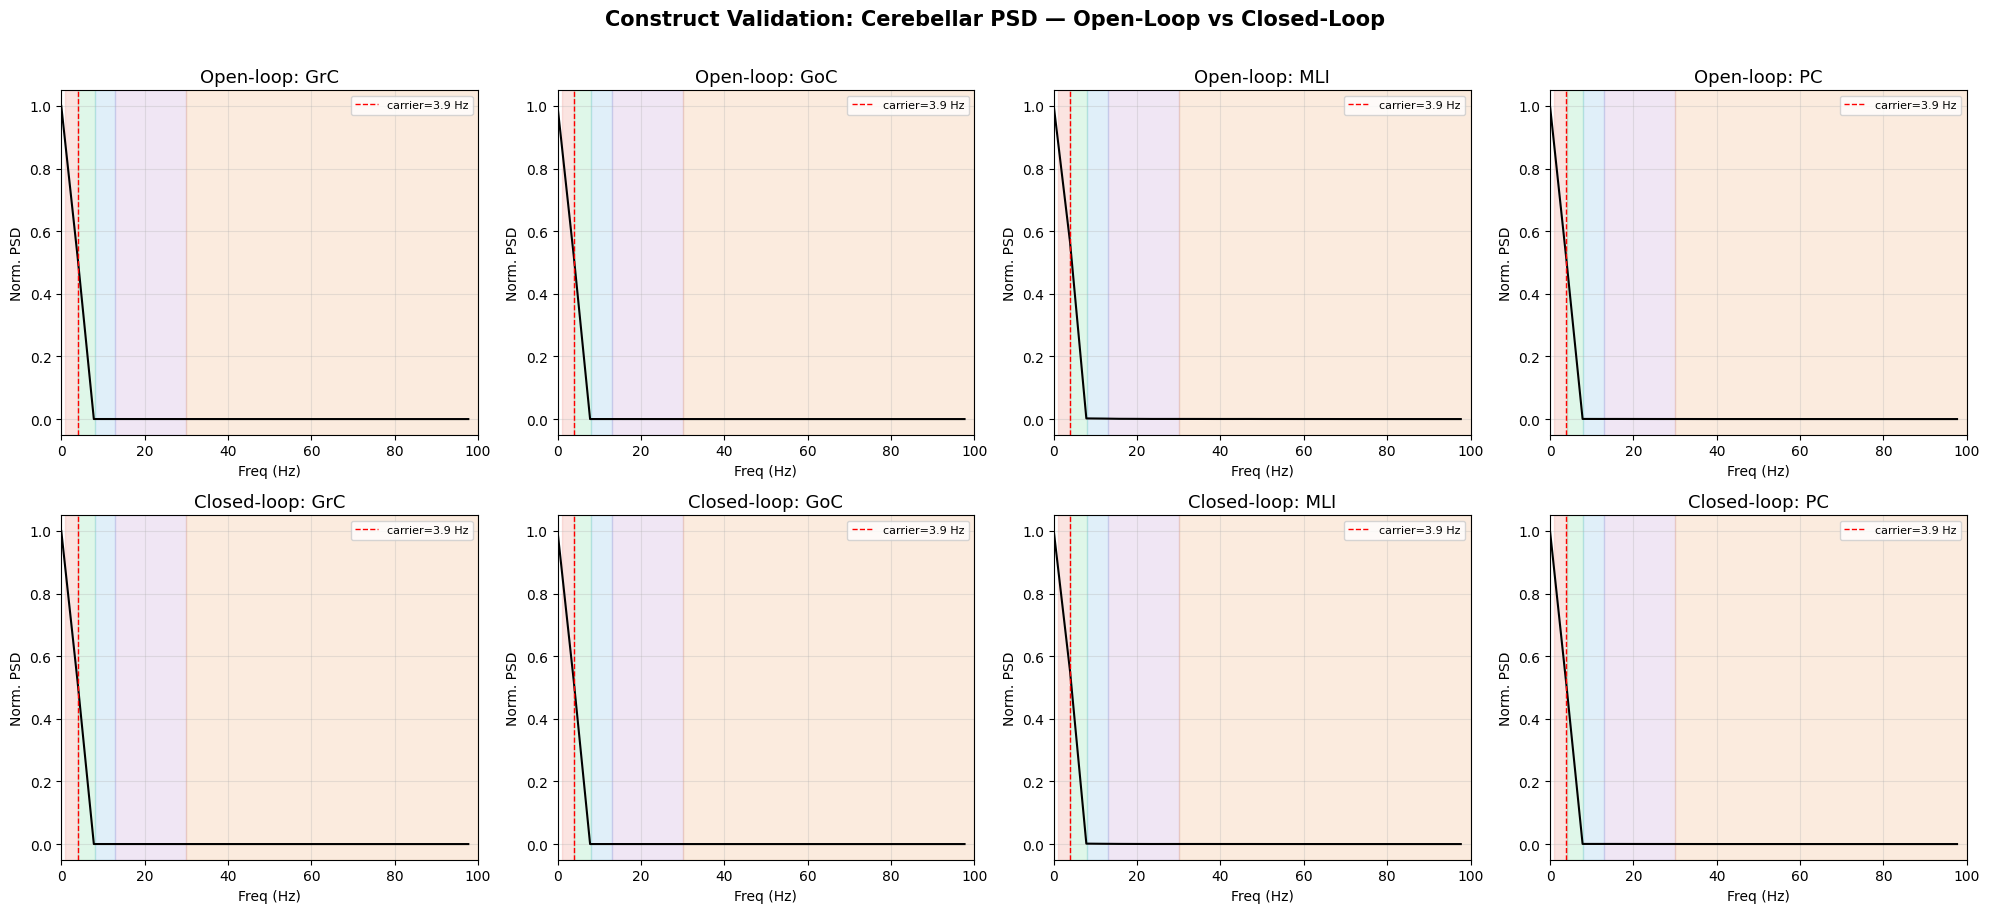

PSD comparison plot saved


In [10]:
pops = ['GrC', 'GoC', 'MLI', 'PC']
fig, axes = plt.subplots(2, 4, figsize=(20, 9))

for ci, pop in enumerate(pops):
    # Row 0: Open-loop
    ax = axes[0, ci]
    f, p = psd_open[pop]
    p_norm = p / p.max() if p.max() > 0 else p
    mask = f <= 100
    ax.plot(f[mask], p_norm[mask], 'k-', lw=1.5)
    ax.axvline(carrier_open[pop], color='red', ls='--', lw=1,
               label=f'carrier={carrier_open[pop]:.1f} Hz')
    for bn, (blo, bhi) in bands.items():
        ax.axvspan(blo, bhi, color=band_colors[bn], alpha=0.15)
    ax.set_title(f'Open-loop: {pop}', fontsize=13)
    ax.set_xlabel('Freq (Hz)'); ax.set_ylabel('Norm. PSD')
    ax.legend(fontsize=8); ax.set_xlim(0, 100); ax.grid(True, alpha=0.3)

    # Row 1: Closed-loop
    ax = axes[1, ci]
    f, p = psd_closed[pop]
    p_norm = p / p.max() if p.max() > 0 else p
    mask = f <= 100
    ax.plot(f[mask], p_norm[mask], 'k-', lw=1.5)
    ax.axvline(carrier_closed[pop], color='red', ls='--', lw=1,
               label=f'carrier={carrier_closed[pop]:.1f} Hz')
    for bn, (blo, bhi) in bands.items():
        ax.axvspan(blo, bhi, color=band_colors[bn], alpha=0.15)
    ax.set_title(f'Closed-loop: {pop}', fontsize=13)
    ax.set_xlabel('Freq (Hz)'); ax.set_ylabel('Norm. PSD')
    ax.legend(fontsize=8); ax.set_xlim(0, 100); ax.grid(True, alpha=0.3)

fig.suptitle('Construct Validation: Cerebellar PSD — Open-Loop vs Closed-Loop',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('ww_crbl_psd_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("PSD comparison plot saved")

## 9. Direct spectral overlay — Open vs Closed
#
Overlay the PSDs for each population to visualize the spectral shift
caused by cortical input through mossy fibers.

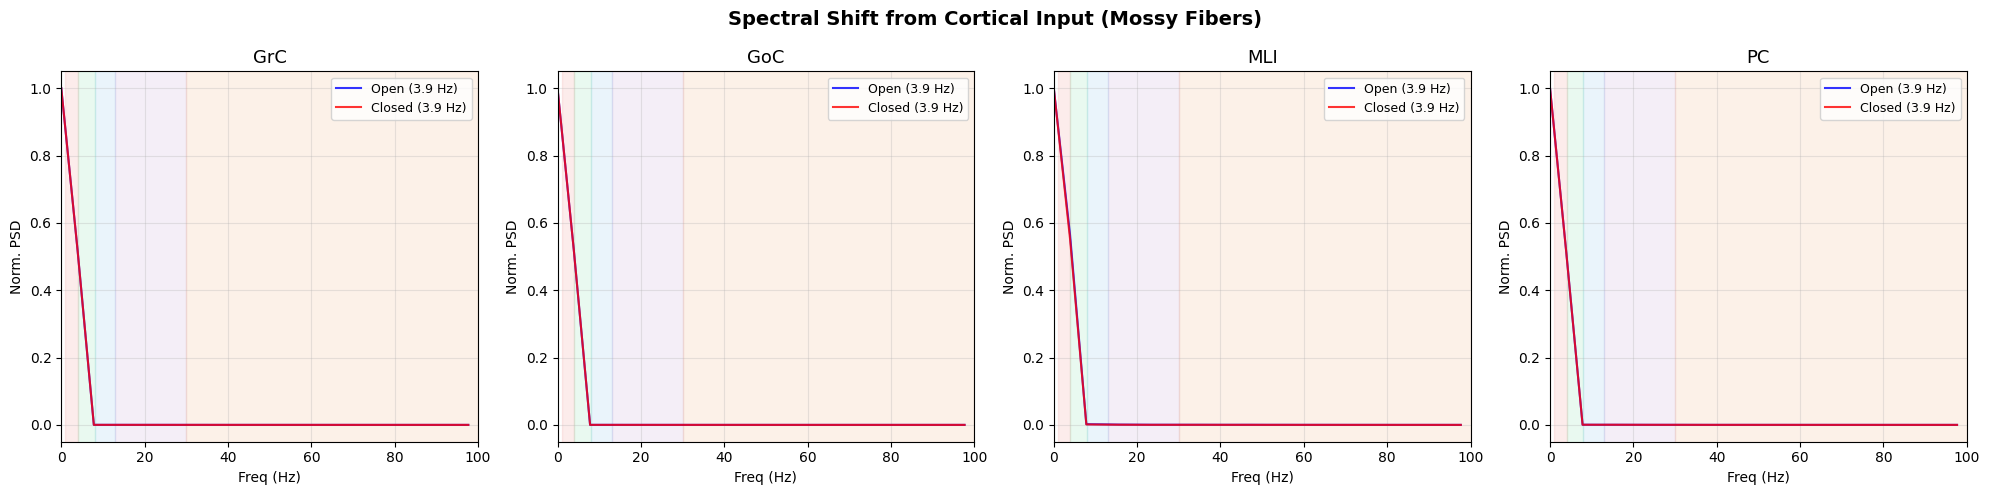

Overlay plot saved


In [11]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ci, pop in enumerate(pops):
    ax = axes[ci]
    f_o, p_o = psd_open[pop]
    p_o_n = p_o / p_o.max() if p_o.max() > 0 else p_o
    f_c, p_c = psd_closed[pop]
    p_c_n = p_c / p_c.max() if p_c.max() > 0 else p_c

    mo = f_o <= 100; mc = f_c <= 100
    ax.plot(f_o[mo], p_o_n[mo], 'b-', lw=1.5, alpha=0.8,
            label=f'Open ({carrier_open[pop]:.1f} Hz)')
    ax.plot(f_c[mc], p_c_n[mc], 'r-', lw=1.5, alpha=0.8,
            label=f'Closed ({carrier_closed[pop]:.1f} Hz)')

    for bn, (blo, bhi) in bands.items():
        ax.axvspan(blo, bhi, color=band_colors[bn], alpha=0.1)

    ax.set_title(pop, fontsize=13)
    ax.set_xlabel('Freq (Hz)'); ax.set_ylabel('Norm. PSD')
    ax.legend(fontsize=9); ax.set_xlim(0, 100); ax.grid(True, alpha=0.3)

fig.suptitle('Spectral Shift from Cortical Input (Mossy Fibers)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ww_crbl_psd_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print("Overlay plot saved")

## 10. Carrier Frequency Summary

In [12]:
print("=" * 55)
print("CARRIER FREQUENCIES (Hz)")
print("=" * 55)
print(f"{'Population':<12} {'Open-loop':>12} {'Closed-loop':>12} {'Δ':>10}")
print("-" * 50)
for pop in pops:
    o = carrier_open[pop]
    c = carrier_closed[pop]
    delta = c - o
    print(f"{pop:<12} {o:>12.1f} {c:>12.1f} {delta:>+10.1f}")
print("-" * 50)
print(f"{'Cortex S_e':<12} {'—':>12} {carrier_se:>12.1f}")
print("=" * 55)

CARRIER FREQUENCIES (Hz)
Population      Open-loop  Closed-loop          Δ
--------------------------------------------------
GrC                   3.9          3.9       +0.0
GoC                   3.9          3.9       +0.0
MLI                   3.9          3.9       +0.0
PC                    3.9          3.9       +0.0
--------------------------------------------------
Cortex S_e              —          3.9


## 11. Time Series Overview

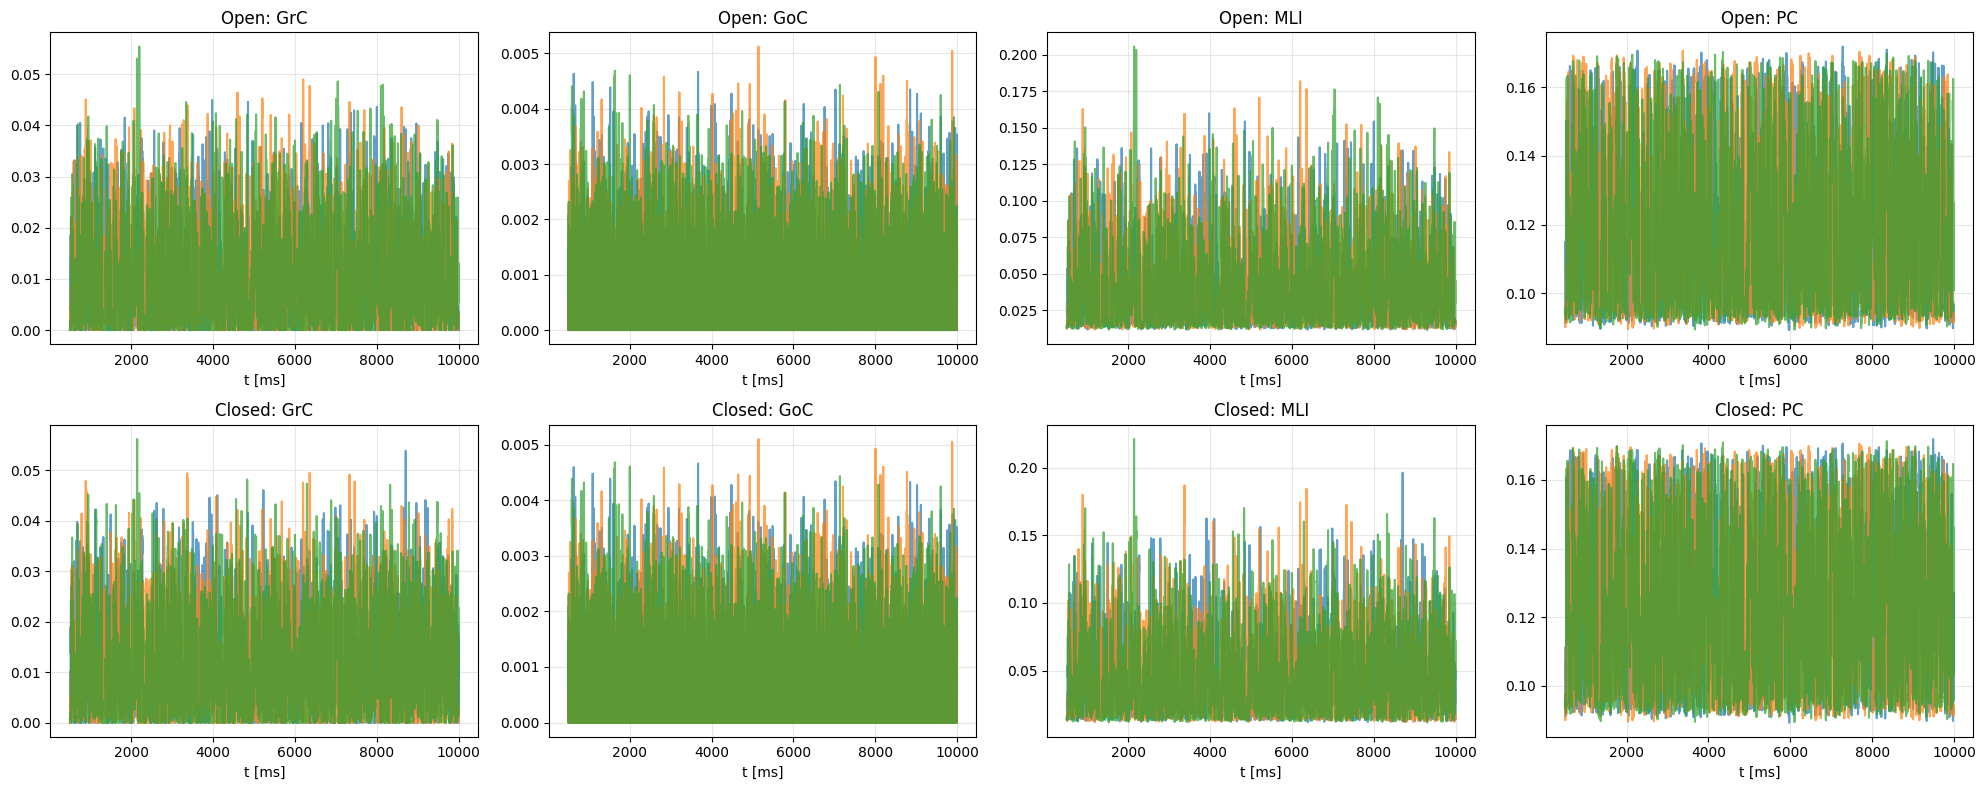

Time series plot saved


In [13]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ci, (pop, o_arr, c_arr) in enumerate([
    ('GrC', grc_open, grc_closed), ('GoC', goc_open, goc_closed),
    ('MLI', mli_open, mli_closed), ('PC', pc_open, pc_closed),
]):
    # Skip initial transient
    skip = 500
    axes[0, ci].plot(ts_open[skip:], o_arr[skip:, :3], alpha=0.7)
    axes[0, ci].set_title(f'Open: {pop}'); axes[0, ci].set_xlabel('t [ms]')
    axes[0, ci].grid(True, alpha=0.3)

    axes[1, ci].plot(ts_r[skip:], c_arr[skip:, :3], alpha=0.7)
    axes[1, ci].set_title(f'Closed: {pop}'); axes[1, ci].set_xlabel('t [ms]')
    axes[1, ci].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ww_crbl_timeseries.png', dpi=150)
plt.show()
print("Time series plot saved")

## 12. Functional Connectivity (Closed-Loop Cortex)

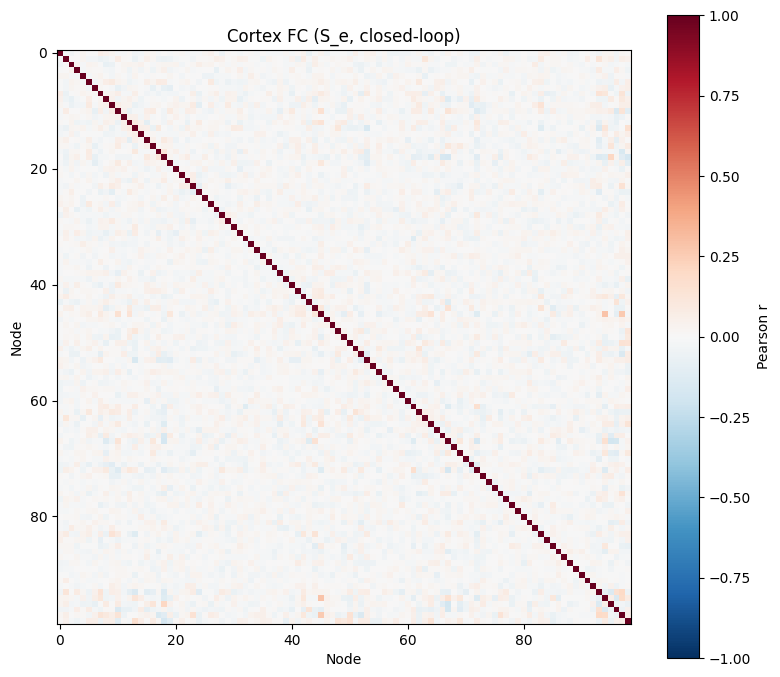

FC plot saved


In [14]:
skip = 500
se_clean = se_closed[skip:, :]
fc = np.corrcoef(se_clean.T)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(fc, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_title('Cortex FC (S_e, closed-loop)')
ax.set_xlabel('Node'); ax.set_ylabel('Node')
plt.colorbar(im, ax=ax, label='Pearson r')
plt.tight_layout()
plt.savefig('ww_crbl_fc.png', dpi=150)
plt.show()
print("FC plot saved")

## 13. Summary & Interpretation
#
This demo performs **construct validation** of the cerebellar MF model
within the TVB hybrid framework by comparing two scenarios:
#
1. **Open-loop (CRBL-only)**: Cerebellum in isolation, driven only by noise.
   Reveals the intrinsic oscillation hierarchy of the GrC → GoC → MLI → PC circuit.
#
2. **Closed-loop (WW+CRBL)**: Full whole-brain simulation with cortical
   input via mossy fibers. Tests whether structured cortical drive
   entrains cerebellar oscillations.
#
**Key findings to check**:
#
- **PC carrier frequency**: Should fall in the alpha band (8–13 Hz) —
  the classic Purkinje-cell simple-spike rhythm.
- **GrC carrier frequency**: Should be in gamma/high beta (30–100 Hz) —
  reflecting fast granule-cell processing.
- **Closed-loop shift**: Cortical input through mossy fibers should
  modulate the cerebellar spectral profile, potentially shifting
  PC power toward the cortical carrier frequency.
- **GrC entrainment**: In closed-loop, GrC oscillations may be pulled
  toward lower frequencies by the cortical drive.
#
The hybrid framework naturally decomposes the monolithic cMF-TVB model's
index-mask-based signal routing into explicit, composable projections
(P1–P4), making the communication architecture transparent and extensible.